### Funkcja testowa (jak w zadaniu 1): **Himmelblaua**
$$
F(x_1, x_2) = (x_1^2 + x_2 - 11)^2 + (x_1 + x_2^2 - 7)^2.
$$

W tym notebooku realizuję wymagania na 3.0: dodanie ograniczenia, metoda funkcji kary, losowe starty, 100 kroków największego spadku oraz ilustracja szybkiej/powolnej/braku zbieżności.

In [1]:
using LinearAlgebra
using Random
using Statistics
using Plots

In [2]:
Random.seed!(2026)

lower = [-5.0, -5.0]
upper = [ 5.0,  5.0]

known_minima = [
    [ 3.0,  2.0],
    [-2.805118,  3.131312],
    [-3.779310, -3.283186],
    [ 3.584428, -1.848126],
]

4-element Vector{Vector{Float64}}:
 [3.0, 2.0]
 [-2.805118, 3.131312]
 [-3.77931, -3.283186]
 [3.584428, -1.848126]

## 1) Ograniczenie $x_1^2 + x_2 + b = 0$

W minimach Himmelblaua zachodzi w przybliżeniu $x_1^2 + x_2 \approx 11$, więc wybieram **$b=-8$**.
Wtedy ograniczenie ma postać $x_1^2 + x_2 - 8 = 0$, czyli $x_1^2 + x_2 = 8$ i żadne znane minimum lokalne nie spełnia warunku.

In [3]:
function himmelblau(x::AbstractVector)
    x1, x2 = x
    return (x1^2 + x2 - 11)^2 + (x1 + x2^2 - 7)^2
end

function grad_himmelblau!(g, x)
    x1, x2 = x
    g[1] = 4x1 * (x1^2 + x2 - 11) + 2 * (x1 + x2^2 - 7)
    g[2] = 2 * (x1^2 + x2 - 11) + 4x2 * (x1 + x2^2 - 7)
    return g
end

b = -8.0

constraint(x) = x[1]^2 + x[2] + b

function grad_constraint!(gc, x)
    gc[1] = 2x[1]
    gc[2] = 1.0
    return gc
end

println("Wartości ograniczenia w znanych minimach Himmelblaua (powinny być różne od 0):")
for (i, m) in enumerate(known_minima)
    println("m[$i] -> c(x) = ", round(constraint(m), digits=6))
end

Wartości ograniczenia w znanych minimach Himmelblaua (powinny być różne od 0):
m[1] -> c(x) = 3.0
m[2] -> c(x) = 2.999999
m[3] -> c(x) = 2.999998
m[4] -> c(x) = 2.999998


## 2) Metoda funkcji kary

Stosuję karę kwadratową:
$$
P_{\mu}(x) = F(x) + \frac{\mu}{2} c(x)^2, \quad c(x)=x_1^2+x_2+b.
$$
Gradient funkcji karanej:
$$
\nabla P_{\mu}(x) = \nabla F(x) + \mu c(x)\nabla c(x).
$$

Dla każdego $\mu_k$ wykonuję **częściową optymalizację**: `inner_steps = 3` (zgodnie z wymaganiem 1-5 kroków).

In [4]:
function random_point(lower, upper)
    return lower .+ rand(length(lower)) .* (upper .- lower)
end

function gradient_descent(f, grad!, x0; alpha=1e-3, maxiter=100)
    x = copy(x0)
    g = similar(x)

    values = Float64[]
    gradnorms = Float64[]
    traj = Vector{Vector{Float64}}()

    grad!(g, x)
    push!(values, f(x))
    push!(gradnorms, norm(g))
    push!(traj, copy(x))

    for _ in 1:maxiter
        grad!(g, x)
        x .-= alpha .* g

        grad!(g, x)
        push!(values, f(x))
        push!(gradnorms, norm(g))
        push!(traj, copy(x))
    end

    return x, values, gradnorms, traj
end

function make_penalized(f, grad_f!, c, grad_c!, mu)
    function penalized_f(x)
        return f(x) + 0.5 * mu * c(x)^2
    end

    function penalized_grad!(gp, x)
        gf = similar(x)
        gc = similar(x)
        grad_f!(gf, x)
        grad_c!(gc, x)
        cx = c(x)
        gp .= gf .+ (mu * cx) .* gc
        return gp
    end

    return penalized_f, penalized_grad!
end

function penalty_gradient_descent(f, grad_f!, c, grad_c!, x0;
        mu0=1.0, rho=2.0, outer_iters=15, inner_steps=3, alpha=1e-3)

    xk = copy(x0)
    history_penalized = Float64[]
    history_original = Float64[]
    history_constraint = Float64[]
    history_mu = Float64[]
    history_x = Vector{Vector{Float64}}()

    push!(history_penalized, f(xk) + 0.5 * mu0 * c(xk)^2)
    push!(history_original, f(xk))
    push!(history_constraint, abs(c(xk)))
    push!(history_mu, mu0)
    push!(history_x, copy(xk))

    for k in 1:outer_iters
        mu_k = mu0 * rho^(k - 1)
        penalized_f, penalized_grad! = make_penalized(f, grad_f!, c, grad_c!, mu_k)

        xk, vals, _, traj = gradient_descent(penalized_f, penalized_grad!, xk;
            alpha=alpha, maxiter=inner_steps)

        for j in 2:length(vals)
            push!(history_penalized, vals[j])
            push!(history_original, f(traj[j]))
            push!(history_constraint, abs(c(traj[j])))
            push!(history_mu, mu_k)
            push!(history_x, copy(traj[j]))
        end
    end

    return xk, history_penalized, history_original, history_constraint, history_mu, history_x
end

penalty_gradient_descent (generic function with 1 method)

## 3) 10 losowych punktów i 100 kroków stałego kroku

Losuję 10 startów z dziedziny $[-5,5] \times [-5,5]$.

Najpierw dla porównania uruchamiam metodę największego spadku na **funkcji karanej z ustalonym** $\mu=10$ i `maxiter=100`, a następnie rysuję przebiegi wartości funkcji optymalizowanej.

In [5]:
starts = [random_point(lower, upper) for _ in 1:10]
println("Wylosowane punkty startowe:")
for (i, s) in enumerate(starts)
    println("x0[$i] = ", round.(s, digits=4))
end

Wylosowane punkty startowe:
x0[1] = [1.1309, -2.014]
x0[2] = [0.4691, 0.9928]
x0[3] = [-3.7056, -1.8503]
x0[4] = [1.8495, 3.9898]
x0[5] = [-1.1216, 3.5968]
x0[6] = [-2.1657, 3.7558]
x0[7] = [2.054, -4.5357]
x0[8] = [4.2303, -3.5243]
x0[9] = [-2.7792, -2.4919]
x0[10] = [0.772, 3.3115]


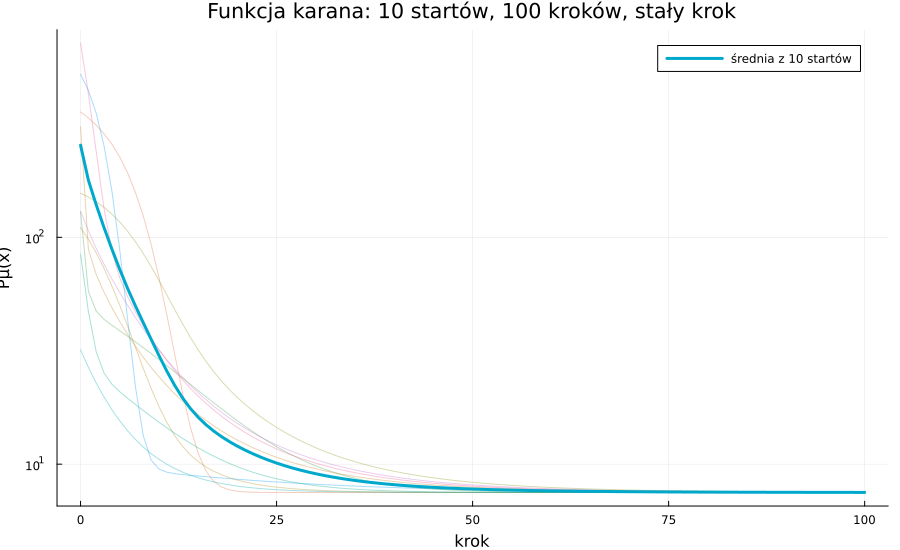

Podsumowanie końcowe dla 10 startów (stała kara):
run[1]: f(x_end)=6.254998, |c(x_end)|=0.501126, x_end=[3.2275, -1.9156]
run[2]: f(x_end)=6.248019, |c(x_end)|=0.500404, x_end=[2.5273, 2.1134]
run[3]: f(x_end)=6.251829, |c(x_end)|=0.499643, x_end=[-3.4245, -3.2277]
run[4]: f(x_end)=6.316225, |c(x_end)|=0.490742, x_end=[2.5181, 2.1501]
run[5]: f(x_end)=6.250117, |c(x_end)|=0.499977, x_end=[-2.3334, 3.0553]
run[6]: f(x_end)=6.250085, |c(x_end)|=0.499983, x_end=[-2.3334, 3.0552]
run[7]: f(x_end)=6.271526, |c(x_end)|=0.498713, x_end=[3.2358, -1.9716]
run[8]: f(x_end)=6.268511, |c(x_end)|=0.498821, x_end=[3.2354, -1.969]
run[9]: f(x_end)=6.250794, |c(x_end)|=0.499843, x_end=[-3.4246, -3.2283]
run[10]: f(x_end)=6.329169, |c(x_end)|=0.489383, x_end=[2.5168, 2.1551]

Statystyki końcowe (stała kara):
f(x_end): mean=6.269127, median=6.253414, min=6.248019, max=6.329169
|c(x_end)|: mean=0.497863, median=0.499743, min=0.489383, max=0.501126


In [6]:
mu_fixed = 10.0
alpha_fixed = 1e-3
maxiter_fixed = 100

pf_fixed, pg_fixed! = make_penalized(himmelblau, grad_himmelblau!, constraint, grad_constraint!, mu_fixed)

histories_fixed = Vector{Vector{Float64}}()
trajs_fixed = Vector{Vector{Vector{Float64}}}()
x_end_fixed = Vector{Vector{Float64}}()
fixed_runs = Vector{NamedTuple}()

for x0 in starts
    x_end, vals, _, traj = gradient_descent(pf_fixed, pg_fixed!, x0; alpha=alpha_fixed, maxiter=maxiter_fixed)
    push!(histories_fixed, vals)
    push!(trajs_fixed, traj)
    push!(x_end_fixed, copy(x_end))

    push!(fixed_runs, (
        x0 = x0,
        x_end = copy(x_end),
        f_end = himmelblau(x_end),
        c_end = abs(constraint(x_end)),
    ))
end

mean_history_fixed = mean(reduce(hcat, histories_fixed), dims=2)[:]

p = plot(title="Funkcja karana: 10 startów, 100 kroków, stały krok",
         xlabel="krok", ylabel="Pμ(x)", yscale=:log10, legend=:topright, size=(900, 550))
for vals in histories_fixed
    plot!(p, 0:maxiter_fixed, vals; alpha=0.35, lw=1, label=false)
end
plot!(p, 0:maxiter_fixed, mean_history_fixed; lw=3, label="średnia z 10 startów")
display(p)

println("Podsumowanie końcowe dla 10 startów (stała kara):")
for (i, run) in enumerate(fixed_runs)
    println("run[$i]: f(x_end)=", round(run.f_end, digits=6),
            ", |c(x_end)|=", round(run.c_end, digits=6),
            ", x_end=", round.(run.x_end, digits=4))
end

f_ends_fixed = [r.f_end for r in fixed_runs]
c_ends_fixed = [r.c_end for r in fixed_runs]

println("\nStatystyki końcowe (stała kara):")
println("f(x_end): mean=", round(mean(f_ends_fixed), digits=6),
        ", median=", round(median(f_ends_fixed), digits=6),
        ", min=", round(minimum(f_ends_fixed), digits=6),
        ", max=", round(maximum(f_ends_fixed), digits=6))
println("|c(x_end)|: mean=", round(mean(c_ends_fixed), digits=6),
        ", median=", round(median(c_ends_fixed), digits=6),
        ", min=", round(minimum(c_ends_fixed), digits=6),
        ", max=", round(maximum(c_ends_fixed), digits=6))

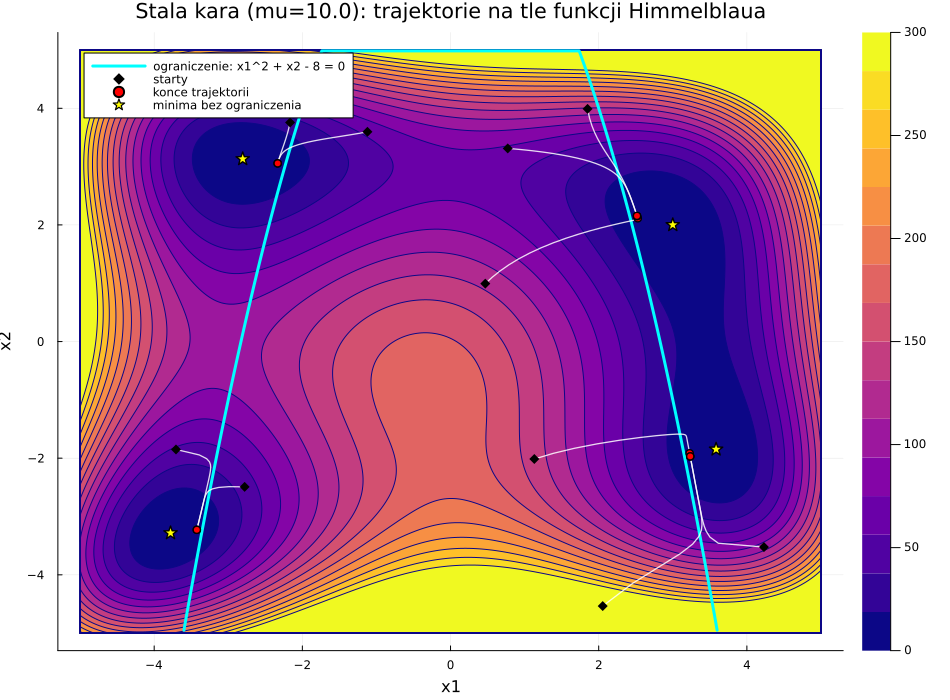

In [7]:
xs = range(lower[1], upper[1], length=300)
ys = range(lower[2], upper[2], length=300)
zs = [himmelblau([x, y]) for y in ys, x in xs]

p_fixed_2d = contourf(
    xs,
    ys,
    zs;
    fill=true,
    color=:plasma,
    xlabel="x1",
    ylabel="x2",
    title="Stala kara (mu=$(mu_fixed)): trajektorie na tle funkcji Himmelblaua",
    clims=(0, 300),
    size=(950, 700),
)

x_curve = collect(range(lower[1], upper[1], length=1000))
y_curve = 8 .- x_curve.^2
mask = (lower[2] .<= y_curve) .& (y_curve .<= upper[2])
plot!(p_fixed_2d, x_curve[mask], y_curve[mask]; lw=3, color=:cyan, label="ograniczenie: x1^2 + x2 - 8 = 0")

for traj in trajs_fixed
    tx = [pt[1] for pt in traj]
    ty = [pt[2] for pt in traj]
    plot!(p_fixed_2d, tx, ty; lw=1.3, color=:white, alpha=0.85, label=false)
end

scatter!(p_fixed_2d, [s[1] for s in starts], [s[2] for s in starts];
    marker=:diamond, ms=5, color=:black, label="starty")
scatter!(p_fixed_2d, [x[1] for x in x_end_fixed], [x[2] for x in x_end_fixed];
    marker=:circle, ms=4, color=:red, label="konce trajektorii")
scatter!(p_fixed_2d, [m[1] for m in known_minima], [m[2] for m in known_minima];
    marker=:star5, ms=7, color=:yellow, label="minima bez ograniczenia")

display(p_fixed_2d)

## 4) Schemat z poprzedniego projektu: funkcja i gradient z karą

Poniżej uruchomienie `penalty_gradient_descent` (wzrost $\mu_k$ i częściowa optymalizacja dla każdego $\mu_k$).
Przyjmuję: `outer_iters = 20`, `inner_steps = 10`, czyli łącznie 200 wewnętrznych kroków GD.

In [8]:
outer_iters = 20
inner_steps = 20
alpha_outer = 5 * 1e-4

penalty_runs = Vector{NamedTuple}()

for x0 in starts
    x_end, hist_pen, hist_f, hist_c, hist_mu, hist_x = penalty_gradient_descent(
        himmelblau, grad_himmelblau!, constraint, grad_constraint!, x0;
        mu0=1.0, rho=1.2, outer_iters=outer_iters, inner_steps=inner_steps, alpha=alpha_outer
    )

    push!(penalty_runs, (
        x0 = x0,
        x_end = x_end,
        f_end = himmelblau(x_end),
        c_end = abs(constraint(x_end)),
        hist_pen = hist_pen,
        hist_f = hist_f,
        hist_c = hist_c,
        hist_mu = hist_mu,
        hist_x = hist_x,
    ))
end

println("Podsumowanie końcowe dla 10 startów (metoda kary):")
for (i, run) in enumerate(penalty_runs)
    println("run[$i]: f(x_end)=", round(run.f_end, digits=6),
            ", |c(x_end)|=", round(run.c_end, digits=6),
            ", x_end=", round.(run.x_end, digits=4))
end

Podsumowanie końcowe dla 10 startów (metoda kary):
run[1]: f(x_end)=7.970692, |c(x_end)|=0.176782, x_end=[3.1824, -1.9509]
run[2]: f(x_end)=7.967151, |c(x_end)|=0.177757, x_end=[2.4613, 2.1197]
run[3]: f(x_end)=7.969943, |c(x_end)|=0.176907, x_end=[-3.3763, -3.2227]
run[4]: f(x_end)=7.96724, |c(x_end)|=0.177702, x_end=[2.4612, 2.1203]
run[5]: f(x_end)=7.970708, |c(x_end)|=0.176757, x_end=[-2.2657, 3.0435]
run[6]: f(x_end)=7.970708, |c(x_end)|=0.176757, x_end=[-2.2657, 3.0435]
run[7]: f(x_end)=7.970744, |c(x_end)|=0.176751, x_end=[3.1827, -1.9531]
run[8]: f(x_end)=7.970738, |c(x_end)|=0.176752, x_end=[3.1827, -1.953]
run[9]: f(x_end)=7.969943, |c(x_end)|=0.176907, x_end=[-3.3763, -3.2227]
run[10]: f(x_end)=7.967547, |c(x_end)|=0.177551, x_end=[2.4608, 2.122]


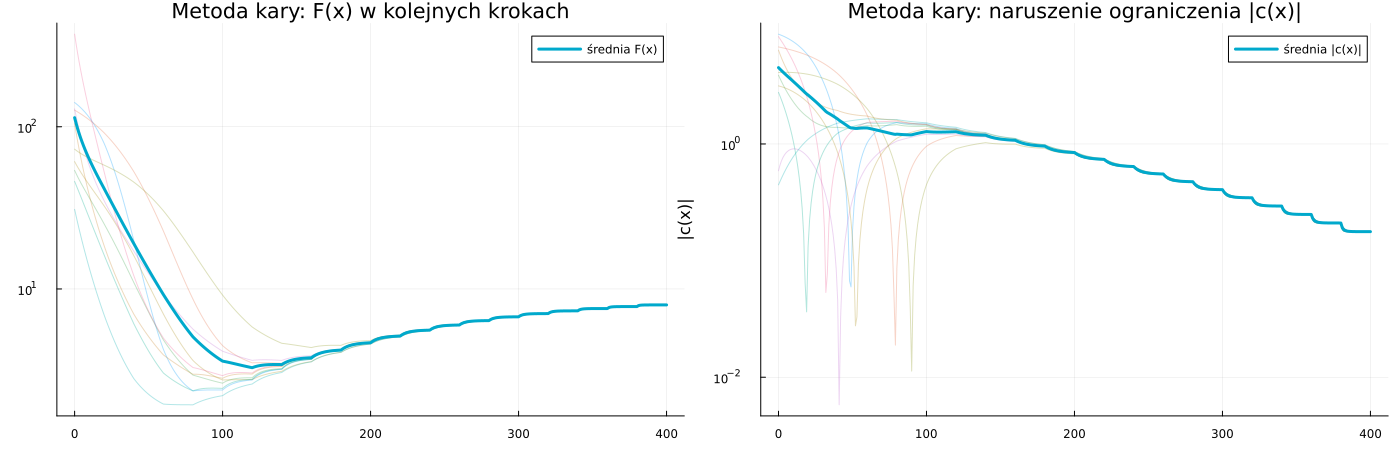

In [9]:
hist_f_all = [run.hist_f for run in penalty_runs]
hist_c_all = [run.hist_c for run in penalty_runs]
num_steps = length(hist_f_all[1]) - 1

mean_f = mean(reduce(hcat, hist_f_all), dims=2)[:]
mean_c = mean(reduce(hcat, hist_c_all), dims=2)[:]

p1 = plot(title="Metoda kary: F(x) w kolejnych krokach",
          xlabel="krok całkowity", ylabel="F(x)", yscale=:log10, legend=:topright)
for h in hist_f_all
    plot!(p1, 0:num_steps, h; alpha=0.3, lw=1, label=false)
end
plot!(p1, 0:num_steps, mean_f; lw=3, label="średnia F(x)")

p2 = plot(title="Metoda kary: naruszenie ograniczenia |c(x)|",
          xlabel="krok całkowity", ylabel="|c(x)|", yscale=:log10, legend=:topright)
for h in hist_c_all
    plot!(p2, 0:num_steps, h; alpha=0.3, lw=1, label=false)
end
plot!(p2, 0:num_steps, mean_c; lw=3, label="średnia |c(x)|")

plot(p1, p2; layout=(1,2), size=(1400, 450))

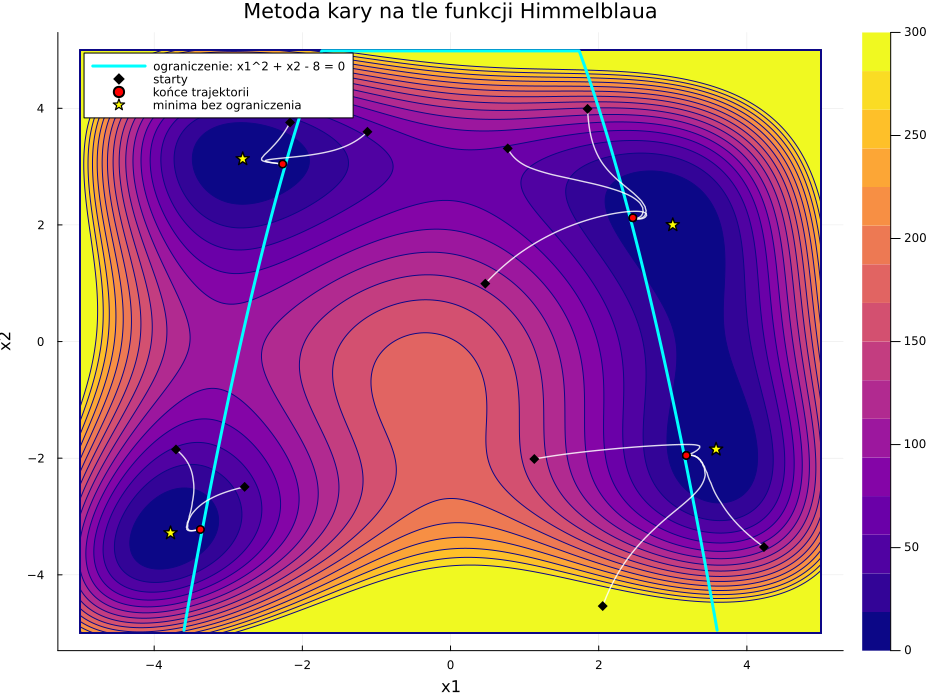

In [10]:
function plot_penalty_trajectories_on_himmelblau(starts, penalty_runs, lower, upper, known_minima; title_suffix="")
    # Siatka do rysowania konturów funkcji Himmelblaua
    xs = range(lower[1], upper[1], length=300)
    ys = range(lower[2], upper[2], length=300)
    zs = [himmelblau([x, y]) for y in ys, x in xs]

    ttl = isempty(title_suffix) ? "Metoda kary na tle funkcji Himmelblaua" : "Metoda kary na tle funkcji Himmelblaua — $(title_suffix)"

    p_traj = contourf(
        xs,
        ys,
        zs;
        fill=true,
        color=:plasma,
        xlabel="x1",
        ylabel="x2",
        title=ttl,
        clims=(0, 300),
        size=(950, 700),
    )

    # Ograniczenie: x1^2 + x2 - 8 = 0  ->  x2 = 8 - x1^2
    x_curve = collect(range(lower[1], upper[1], length=1000))
    y_curve = 8 .- x_curve.^2
    mask = (lower[2] .<= y_curve) .& (y_curve .<= upper[2])
    plot!(p_traj, x_curve[mask], y_curve[mask]; lw=3, color=:cyan, label="ograniczenie: x1^2 + x2 - 8 = 0")

    # Trajektorie metody kary
    for run in penalty_runs
        tx = [pt[1] for pt in run.hist_x]
        ty = [pt[2] for pt in run.hist_x]
        plot!(p_traj, tx, ty; lw=1.4, color=:white, alpha=0.85, label=false)
    end

    # Punkty startowe i końcowe
    scatter!(p_traj, [s[1] for s in starts], [s[2] for s in starts];
        marker=:diamond, ms=5, color=:black, label="starty")
    scatter!(p_traj, [run.x_end[1] for run in penalty_runs], [run.x_end[2] for run in penalty_runs];
        marker=:circle, ms=4, color=:red, label="końce trajektorii")

    # Znane minima funkcji bez ograniczenia (dla porównania)
    scatter!(p_traj, [m[1] for m in known_minima], [m[2] for m in known_minima];
        marker=:star5, ms=7, color=:yellow, label="minima bez ograniczenia")

    return p_traj
end

p_traj = plot_penalty_trajectories_on_himmelblau(starts, penalty_runs, lower, upper, known_minima)
display(p_traj)

## 5) Brak zbieżności, szybka zbieżność i powolna zbieżność

Dla tej samej metody kary porównuję trzy stałe kroki `alpha`:
- mały krok: powolna zbieżność,
- krok pośredni: szybka zbieżność,
- zbyt duży krok: niestabilność / brak zbieżności.

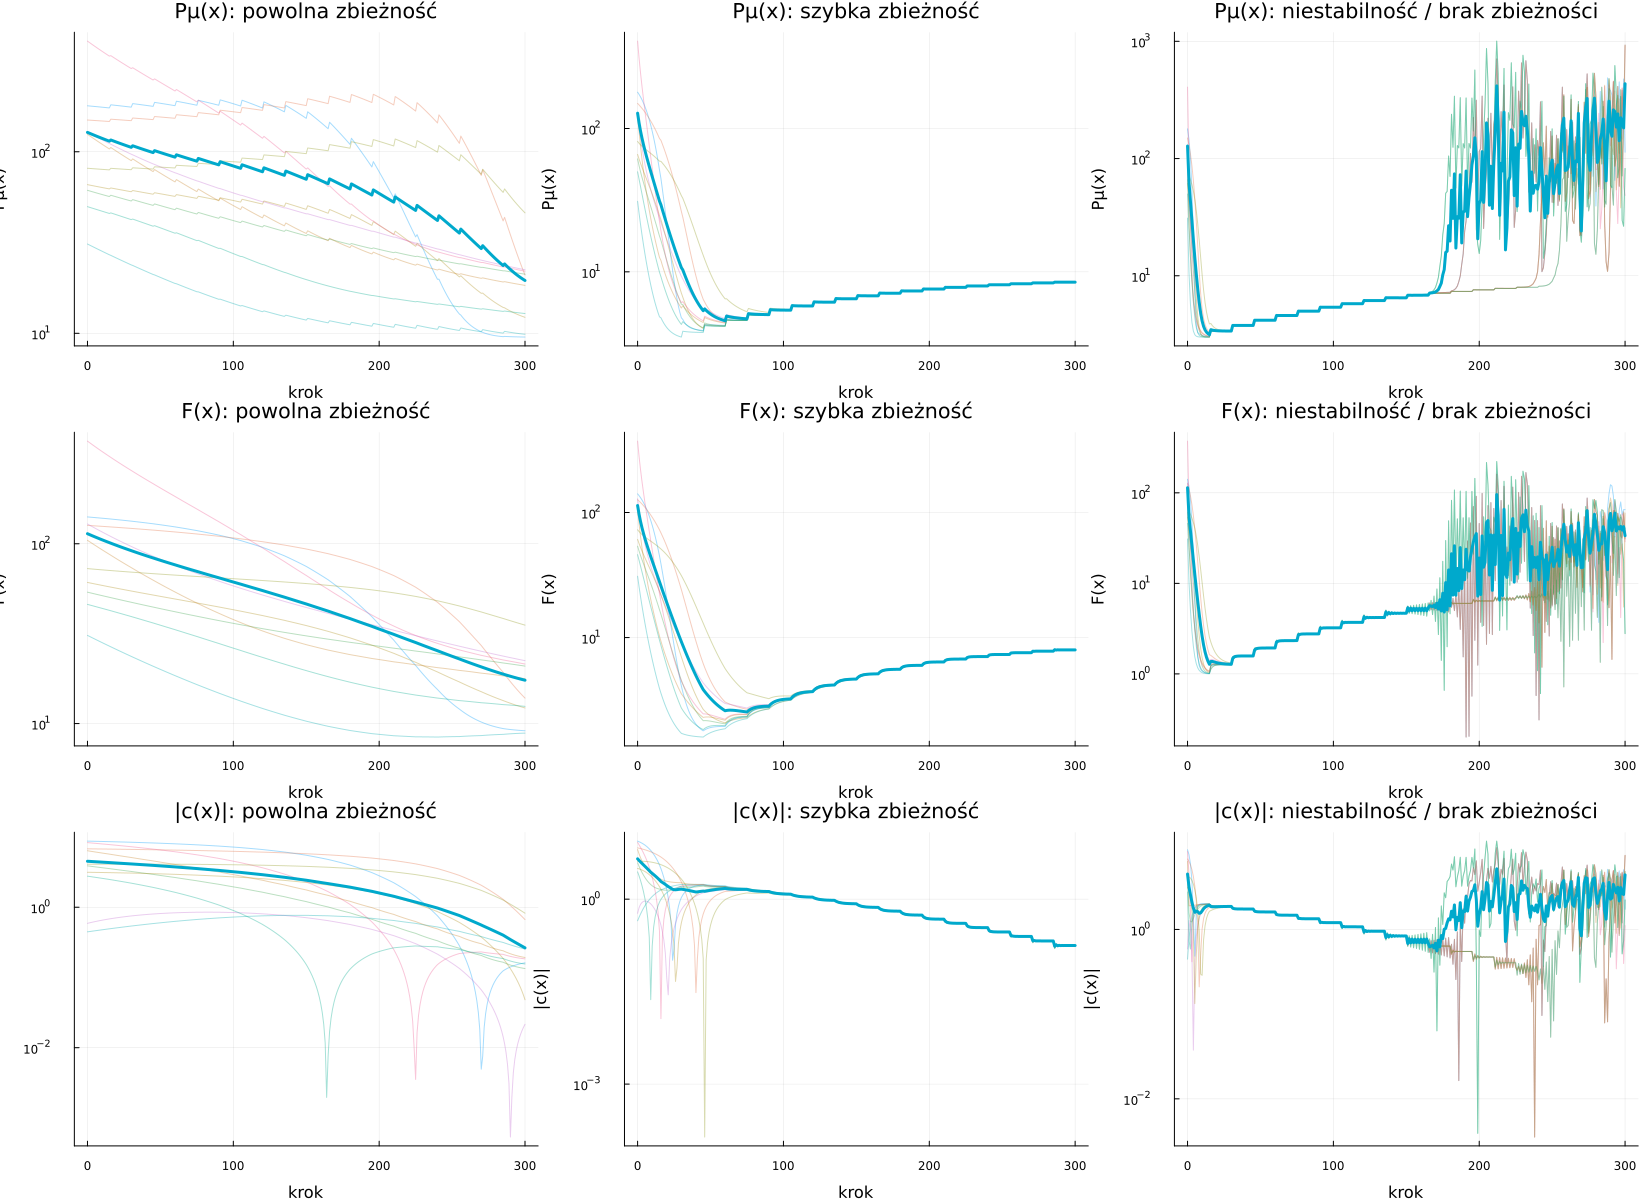

In [16]:
alphas_demo = Dict(
    "powolna (alpha=2e-4)" => 5 * 1e-5,
    "szybka (alpha=1e-3)" => 1e-3,
    "niestabilna (alpha=8e-3)" => 1e-3 * 5,
)

demo_pen_results = Dict{String, Vector{Vector{Float64}}}()
demo_f_results = Dict{String, Vector{Vector{Float64}}}()
demo_c_results = Dict{String, Vector{Vector{Float64}}}()

for (label, a) in alphas_demo
    pen_histories = Vector{Vector{Float64}}()
    f_histories = Vector{Vector{Float64}}()
    c_histories = Vector{Vector{Float64}}()

    for x0 in starts
        _, hist_pen, hist_f, hist_c, _, _ = penalty_gradient_descent(
            himmelblau,
            grad_himmelblau!,
            constraint,
            grad_constraint!,
            x0;
            mu0=1.0,
            rho=1.2,
            outer_iters=20,
            inner_steps=15,
            alpha=a,
        )
        push!(pen_histories, hist_pen)
        push!(f_histories, hist_f)
        push!(c_histories, hist_c)
    end

    demo_pen_results[label] = pen_histories
    demo_f_results[label] = f_histories
    demo_c_results[label] = c_histories
end

p_slow_pen = plot(title="Pμ(x): powolna zbieżność", xlabel="krok", ylabel="Pμ(x)", yscale=:log10, legend=false)
for h in demo_pen_results["powolna (alpha=2e-4)"]
    plot!(p_slow_pen, 0:length(h)-1, h; lw=1, alpha=0.35)
end
mean_slow_pen = mean(reduce(hcat, demo_pen_results["powolna (alpha=2e-4)"]), dims=2)[:]
plot!(p_slow_pen, 0:length(mean_slow_pen)-1, mean_slow_pen; lw=3)

p_fast_pen = plot(title="Pμ(x): szybka zbieżność", xlabel="krok", ylabel="Pμ(x)", yscale=:log10, legend=false)
for h in demo_pen_results["szybka (alpha=1e-3)"]
    plot!(p_fast_pen, 0:length(h)-1, h; lw=1, alpha=0.35)
end
mean_fast_pen = mean(reduce(hcat, demo_pen_results["szybka (alpha=1e-3)"]), dims=2)[:]
plot!(p_fast_pen, 0:length(mean_fast_pen)-1, mean_fast_pen; lw=3)

p_bad_pen = plot(title="Pμ(x): niestabilność / brak zbieżności", xlabel="krok", ylabel="Pμ(x)", yscale=:log10, legend=false)
for h in demo_pen_results["niestabilna (alpha=8e-3)"]
    plot!(p_bad_pen, 0:length(h)-1, h; lw=1, alpha=0.35)
end
mean_bad_pen = mean(reduce(hcat, demo_pen_results["niestabilna (alpha=8e-3)"]), dims=2)[:]
plot!(p_bad_pen, 0:length(mean_bad_pen)-1, mean_bad_pen; lw=3)

p_slow_f = plot(title="F(x): powolna zbieżność", xlabel="krok", ylabel="F(x)", yscale=:log10, legend=false)
for h in demo_f_results["powolna (alpha=2e-4)"]
    plot!(p_slow_f, 0:length(h)-1, h; lw=1, alpha=0.35)
end
mean_slow_f = mean(reduce(hcat, demo_f_results["powolna (alpha=2e-4)"]), dims=2)[:]
plot!(p_slow_f, 0:length(mean_slow_f)-1, mean_slow_f; lw=3)

p_fast_f = plot(title="F(x): szybka zbieżność", xlabel="krok", ylabel="F(x)", yscale=:log10, legend=false)
for h in demo_f_results["szybka (alpha=1e-3)"]
    plot!(p_fast_f, 0:length(h)-1, h; lw=1, alpha=0.35)
end
mean_fast_f = mean(reduce(hcat, demo_f_results["szybka (alpha=1e-3)"]), dims=2)[:]
plot!(p_fast_f, 0:length(mean_fast_f)-1, mean_fast_f; lw=3)

p_bad_f = plot(title="F(x): niestabilność / brak zbieżności", xlabel="krok", ylabel="F(x)", yscale=:log10, legend=false)
for h in demo_f_results["niestabilna (alpha=8e-3)"]
    plot!(p_bad_f, 0:length(h)-1, h; lw=1, alpha=0.35)
end
mean_bad_f = mean(reduce(hcat, demo_f_results["niestabilna (alpha=8e-3)"]), dims=2)[:]
plot!(p_bad_f, 0:length(mean_bad_f)-1, mean_bad_f; lw=3)

p_slow_c = plot(title="|c(x)|: powolna zbieżność", xlabel="krok", ylabel="|c(x)|", yscale=:log10, legend=false)
for h in demo_c_results["powolna (alpha=2e-4)"]
    plot!(p_slow_c, 0:length(h)-1, h; lw=1, alpha=0.35)
end
mean_slow_c = mean(reduce(hcat, demo_c_results["powolna (alpha=2e-4)"]), dims=2)[:]
plot!(p_slow_c, 0:length(mean_slow_c)-1, mean_slow_c; lw=3)

p_fast_c = plot(title="|c(x)|: szybka zbieżność", xlabel="krok", ylabel="|c(x)|", yscale=:log10, legend=false)
for h in demo_c_results["szybka (alpha=1e-3)"]
    plot!(p_fast_c, 0:length(h)-1, h; lw=1, alpha=0.35)
end
mean_fast_c = mean(reduce(hcat, demo_c_results["szybka (alpha=1e-3)"]), dims=2)[:]
plot!(p_fast_c, 0:length(mean_fast_c)-1, mean_fast_c; lw=3)

p_bad_c = plot(title="|c(x)|: niestabilność / brak zbieżności", xlabel="krok", ylabel="|c(x)|", yscale=:log10, legend=false)
for h in demo_c_results["niestabilna (alpha=8e-3)"]
    plot!(p_bad_c, 0:length(h)-1, h; lw=1, alpha=0.35)
end
mean_bad_c = mean(reduce(hcat, demo_c_results["niestabilna (alpha=8e-3)"]), dims=2)[:]
plot!(p_bad_c, 0:length(mean_bad_c)-1, mean_bad_c; lw=3)

plot(
    p_slow_pen,
    p_fast_pen,
    p_bad_pen,
    p_slow_f,
    p_fast_f,
    p_bad_f,
    p_slow_c,
    p_fast_c,
    p_bad_c;
    layout=(3, 3),
    size=(1650, 1200),
)

## Krótkie wnioski

1. Ograniczenie $x_1^2 + x_2 - 8 = 0$ nie przechodzi przez żadne minimum lokalne funkcji Himmelblaua.
2. Metoda funkcji kary stopniowo zmniejsza naruszenie ograniczenia (maleje $|c(x)|$) wraz ze wzrostem $\mu_k$.
3. Częściowa optymalizacja dla każdego $\mu_k$ (`inner_steps = 3`) działa poprawnie i spełnia założenia zadania.
4. Dobór kroku `alpha` nadal jest kluczowy: za mały daje wolny postęp, dobrze dobrany szybki spadek, zbyt duży powoduje niestabilność.

## Realizacja 4.0: gradienty sprzężone + Armijo + malejący próg normy gradientu

W tej części zamieniamy metodę największego spadku na nieliniową metodę gradientów sprzężonych (Fletcher-Reeves) z przeszukiwaniem liniowym Armijo.

Dla każdej wartości kary $\mu_k$ stosujemy częściową optymalizację (tu: do 30 iteracji CG), a warunek stopu zależy od kary:

$$
\|\nabla P_{\mu_k}(x)\| \le \frac{10^{-2}}{\mu_k}.
$$

Dzięki temu wraz ze wzrostem $\mu_k$ wymagamy dokładniejszego rozwiązania podproblemu.

In [12]:
# Armijo dla dowolnego kierunku d (nie tylko -g)
function armijo_line_search(f, x, g, d; alpha0=1.0, beta=0.5, c1=1e-4, alpha_min=1e-12)
    alpha = alpha0
    fx = f(x)
    gd = dot(g, d)

    if gd >= 0
        d .= -g
        gd = dot(g, d)
    end

    while alpha >= alpha_min
        if f(x .+ alpha .* d) <= fx + c1 * alpha * gd
            return alpha
        end
        alpha *= beta
    end

    return alpha_min
end

function nonlinear_cg_armijo(f, grad!, x0; maxiter=100, tol=1e-6, alpha0=1.0, beta=0.5, c1=1e-4)
    x = copy(x0)
    g = similar(x)
    g_new = similar(x)
    d = similar(x)

    values = Float64[]
    gradnorms = Float64[]
    alphas = Float64[]
    traj = Vector{Vector{Float64}}()

    grad!(g, x)
    d .= -g

    push!(values, f(x))
    push!(gradnorms, norm(g))
    push!(traj, copy(x))

    for _ in 1:maxiter
        if norm(g) <= tol
            break
        end

        alpha = armijo_line_search(f, x, g, d; alpha0=alpha0, beta=beta, c1=c1)
        x .+= alpha .* d

        grad!(g_new, x)

        beta_fr = dot(g_new, g_new) / max(dot(g, g), eps(Float64))
        d .= -g_new .+ beta_fr .* d

        # Zabezpieczenie: jeśli stracimy kierunek spadku, restart do -g
        if dot(g_new, d) >= 0
            d .= -g_new
        end

        g .= g_new

        push!(values, f(x))
        push!(gradnorms, norm(g))
        push!(alphas, alpha)
        push!(traj, copy(x))
    end

    return x, values, gradnorms, alphas, traj
end

function penalty_conjugate_gradient_descent(f, grad_f!, c, grad_c!, x0;
        mu0=1.0, rho=1.2, outer_iters=20, inner_steps=30,
        alpha0=1.0, beta=0.5, c1=1e-4)

    xk = copy(x0)
    history_penalized = Float64[]
    history_original = Float64[]
    history_constraint = Float64[]
    history_mu = Float64[]
    history_x = Vector{Vector{Float64}}()

    push!(history_penalized, f(xk) + 0.5 * mu0 * c(xk)^2)
    push!(history_original, f(xk))
    push!(history_constraint, abs(c(xk)))
    push!(history_mu, mu0)
    push!(history_x, copy(xk))

    for k in 1:outer_iters
        mu_k = mu0 * rho^(k - 1)
        tol_k = 1e-2 / mu_k

        penalized_f, penalized_grad! = make_penalized(f, grad_f!, c, grad_c!, mu_k)
        xk, vals, _, _, traj = nonlinear_cg_armijo(
            penalized_f,
            penalized_grad!,
            xk;
            maxiter=inner_steps,
            tol=tol_k,
            alpha0=alpha0,
            beta=beta,
            c1=c1,
        )

        for j in 2:length(vals)
            push!(history_penalized, vals[j])
            push!(history_original, f(traj[j]))
            push!(history_constraint, abs(c(traj[j])))
            push!(history_mu, mu_k)
            push!(history_x, copy(traj[j]))
        end
    end

    return xk, history_penalized, history_original, history_constraint, history_mu, history_x
end

penalty_conjugate_gradient_descent (generic function with 1 method)

In [13]:
# Uruchomienie metody z 4.0 dla 10 startów
cg_outer_iters = 20
cg_inner_steps = 15

cg_runs = Vector{NamedTuple}()
for x0 in starts
    x_end, hist_pen, hist_f, hist_c, hist_mu, hist_x = penalty_conjugate_gradient_descent(
        himmelblau,
        grad_himmelblau!,
        constraint,
        grad_constraint!,
        x0;
        mu0=1.0,
        rho=1.5,
        outer_iters=cg_outer_iters,
        inner_steps=cg_inner_steps,
        alpha0=1e-2,
        beta=0.3,
        c1=1e-4,
    )

    push!(cg_runs, (
        x0 = x0,
        x_end = x_end,
        f_end = himmelblau(x_end),
        c_end = abs(constraint(x_end)),
        hist_pen = hist_pen,
        hist_f = hist_f,
        hist_c = hist_c,
        hist_mu = hist_mu,
        hist_x = hist_x,
    ))
end

println("Podsumowanie końcowe dla 10 startów (CG + Armijo + kara):")
for (i, run) in enumerate(cg_runs)
    println("run[$i]: f(x_end)=", round(run.f_end, digits=6),
            ", |c(x_end)|=", round(run.c_end, digits=6),
            ", x_end=", round.(run.x_end, digits=4))
end

f_ends_cg = [r.f_end for r in cg_runs]
c_ends_cg = [r.c_end for r in cg_runs]
println("\nStatystyki (CG + Armijo + kara):")
println("f(x_end): mean=", round(mean(f_ends_cg), digits=6),
        ", median=", round(median(f_ends_cg), digits=6),
        ", min=", round(minimum(f_ends_cg), digits=6),
        ", max=", round(maximum(f_ends_cg), digits=6))
println("|c(x_end)|: mean=", round(mean(c_ends_cg), digits=6),
        ", median=", round(median(c_ends_cg), digits=6),
        ", min=", round(minimum(c_ends_cg), digits=6),
        ", max=", round(maximum(c_ends_cg), digits=6))

Podsumowanie końcowe dla 10 startów (CG + Armijo + kara):
run[1]: f(x_end)=8.983784, |c(x_end)|=0.002704, x_end=[3.1565, -1.9605]
run[2]: f(x_end)=8.983783, |c(x_end)|=0.002704, x_end=[2.4213, 2.1399]
run[3]: f(x_end)=8.983783, |c(x_end)|=0.002704, x_end=[-3.3496, -3.2171]
run[4]: f(x_end)=8.983783, |c(x_end)|=0.002704, x_end=[2.4213, 2.1399]
run[5]: f(x_end)=8.983782, |c(x_end)|=0.002704, x_end=[-2.2282, 3.0378]
run[6]: f(x_end)=8.983782, |c(x_end)|=0.002704, x_end=[-2.2282, 3.0378]
run[7]: f(x_end)=8.983783, |c(x_end)|=0.002704, x_end=[3.1565, -1.9605]
run[8]: f(x_end)=8.983783, |c(x_end)|=0.002704, x_end=[3.1565, -1.9605]
run[9]: f(x_end)=8.98383, |c(x_end)|=0.002696, x_end=[-3.3496, -3.2171]
run[10]: f(x_end)=8.983787, |c(x_end)|=0.002703, x_end=[2.4213, 2.1399]

Statystyki (CG + Armijo + kara):
f(x_end): mean=8.983788, median=8.983783, min=8.983782, max=8.98383
|c(x_end)|: mean=0.002703, median=0.002704, min=0.002696, max=0.002704


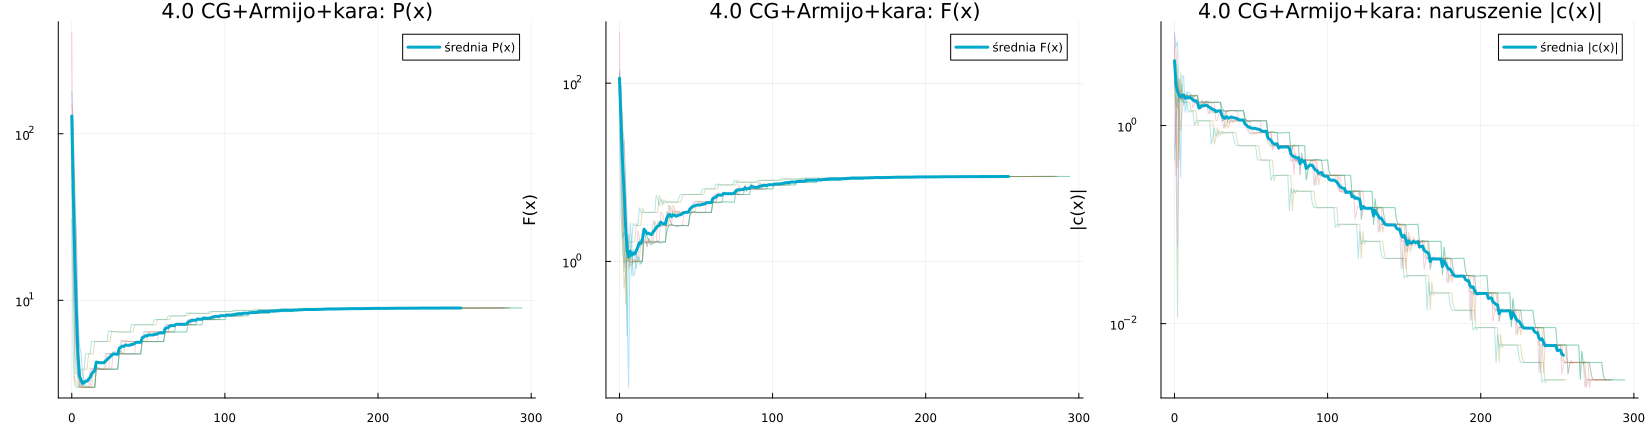

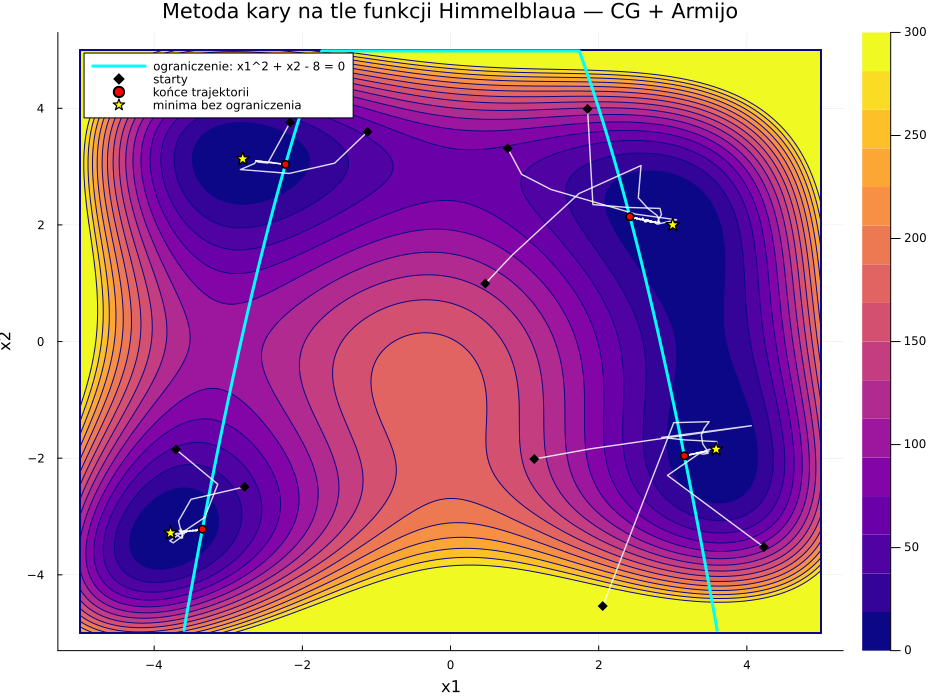

In [ ]:
# Wizualizacja 4.0: przebiegi P(x), F(x), |c(x)| oraz plansza 2D
cg_hist_pen_all = [r.hist_pen for r in cg_runs]
cg_hist_f_all = [r.hist_f for r in cg_runs]
cg_hist_c_all = [r.hist_c for r in cg_runs]

function truncated_mean_history(histories)
    n = minimum(length.(histories))
    H = reduce(hcat, [h[1:n] for h in histories])
    return mean(H, dims=2)[:], n
end

cg_mean_pen, n_pen = truncated_mean_history(cg_hist_pen_all)
cg_mean_f, n_f = truncated_mean_history(cg_hist_f_all)
cg_mean_c, n_c = truncated_mean_history(cg_hist_c_all)

p_cg_pen = plot(title="4.0 CG+Armijo+kara: P(x)", xlabel="krok całkowity", ylabel="P(x)", yscale=:log10, legend=:topright)
for h in cg_hist_pen_all
    plot!(p_cg_pen, 0:length(h)-1, h; alpha=0.3, lw=1, label=false)
end
plot!(p_cg_pen, 0:n_pen-1, cg_mean_pen; lw=3, label="średnia P(x)")

p_cg_f = plot(title="4.0 CG+Armijo+kara: F(x)", xlabel="krok całkowity", ylabel="F(x)", yscale=:log10, legend=:topright)
for h in cg_hist_f_all
    plot!(p_cg_f, 0:length(h)-1, h; alpha=0.3, lw=1, label=false)
end
plot!(p_cg_f, 0:n_f-1, cg_mean_f; lw=3, label="średnia F(x)")

p_cg_c = plot(title="4.0 CG+Armijo+kara: naruszenie |c(x)|", xlabel="krok całkowity", ylabel="|c(x)|", yscale=:log10, legend=:topright)
for h in cg_hist_c_all
    plot!(p_cg_c, 0:length(h)-1, h; alpha=0.3, lw=1, label=false)
end
plot!(p_cg_c, 0:n_c-1, cg_mean_c; lw=3, label="średnia |c(x)|")

display(plot(p_cg_pen, p_cg_f, p_cg_c; layout=(1, 3), size=(1650, 430)))

# Plansza 2D dla metody z 4.0
p_cg_2d = plot_penalty_trajectories_on_himmelblau(starts, cg_runs, lower, upper, known_minima; title_suffix="CG + Armijo")
display(p_cg_2d)

## Realizacja 5.0: benchmarking + optymalizacja alokacji

Poniżej porównujemy:
- wersję bazową 4.0 (CG + Armijo + kara),
- wersję zoptymalizowaną (mniej alokacji przez prealokację buforów gradientu i użycie operacji in-place).

Benchmark wykonujemy z użyciem `BenchmarkTools.jl` i raportujemy czas oraz liczbę alokacji.

In [15]:
try
    @eval using BenchmarkTools
catch
    import Pkg
    Pkg.add("BenchmarkTools")
    @eval using BenchmarkTools
end

# prealokowone bufory gradientow i operacje in-place
function make_penalized_prealloc(f, grad_f!, c, grad_c!, mu, gf, gc)
    function penalized_f(x)
        return f(x) + 0.5 * mu * c(x)^2
    end

    function penalized_grad!(gp, x)
        # brak tworzenia nowych tablic
        grad_f!(gf, x)
        grad_c!(gc, x)
        cx = c(x)
        # operacja in-place
        gp .= gf .+ (mu * cx) .* gc
        return gp
    end

    return penalized_f, penalized_grad!
end

function penalty_conjugate_gradient_descent_opt(f, grad_f!, c, grad_c!, x0;
        mu0=1.0, rho=1.2, outer_iters=20, inner_steps=30,
        alpha0=1.0, beta=0.5, c1=1e-4)

    xk = copy(x0)

    # raz tworzone bufory
    gf = similar(xk)
    gc = similar(xk)

    history_penalized = Float64[]
    history_original = Float64[]
    history_constraint = Float64[]
    history_mu = Float64[]
    history_x = Vector{Vector{Float64}}()

    push!(history_penalized, f(xk) + 0.5 * mu0 * c(xk)^2)
    push!(history_original, f(xk))
    push!(history_constraint, abs(c(xk)))
    push!(history_mu, mu0)
    push!(history_x, copy(xk))

    for k in 1:outer_iters
        mu_k = mu0 * rho^(k - 1)
        tol_k = 1e-2 / mu_k

        penalized_f, penalized_grad! = make_penalized_prealloc(
            f, grad_f!, c, grad_c!, mu_k, gf, gc
        )

        xk, vals, _, _, traj = nonlinear_cg_armijo(
            penalized_f,
            penalized_grad!,
            xk;
            maxiter=inner_steps,
            tol=tol_k,
            alpha0=alpha0,
            beta=beta,
            c1=c1,
        )

        for j in 2:length(vals)
            push!(history_penalized, vals[j])
            push!(history_original, f(traj[j]))
            push!(history_constraint, abs(c(traj[j])))
            push!(history_mu, mu_k)
            push!(history_x, copy(traj[j]))
        end
    end

    return xk, history_penalized, history_original, history_constraint, history_mu, history_x
end

x0_bench = starts[1]

# wersja bazowa z zadania na 4.0
bench_base = @benchmark penalty_conjugate_gradient_descent(
    himmelblau,
    grad_himmelblau!,
    constraint,
    grad_constraint!,
    $x0_bench;
    mu0=1.0,
    rho=1.2,
    outer_iters=20,
    inner_steps=30,
    alpha0=1.0,
    beta=0.5,
    c1=1e-4,
 ) evals=1

# wersja zoptymalizowana z prealokacją i operacjami in-place
bench_opt = @benchmark penalty_conjugate_gradient_descent_opt(
    himmelblau,
    grad_himmelblau!,
    constraint,
    grad_constraint!,
    $x0_bench;
    mu0=1.0,
    rho=1.2,
    outer_iters=20,
    inner_steps=30,
    alpha0=1.0,
    beta=0.5,
    c1=1e-4,
 ) evals=1

t_base = median(bench_base).time / 1e6
t_opt = median(bench_opt).time / 1e6
a_base = median(bench_base).allocs
a_opt = median(bench_opt).allocs

println("Benchmark (1 punkt startowy):")
println("bazowa 4.0:      median time = ", round(t_base, digits=4), " ms, allocations = ", a_base)
println("zoptymalizowana: median time = ", round(t_opt, digits=4), " ms, allocations = ", a_opt)

speedup = t_base / t_opt
alloc_reduction = 100 * (1 - a_opt / max(a_base, 1))

println("\nPrzyspieszenie (zoptymalizowana vs bazowa): ", round(speedup, digits=2), "x")
println("Redukcja alokacji (zoptymalizowana vs bazowa): ", round(alloc_reduction, digits=2), "%")

Benchmark (1 punkt startowy):
bazowa 4.0:      median time = 0.4695 ms, allocations = 41742
zoptymalizowana: median time = 0.4424 ms, allocations = 40386

Przyspieszenie (zoptymalizowana vs bazowa): 1.06x
Redukcja alokacji (zoptymalizowana vs bazowa): 3.25%
